In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_rows', None)


df = pd.read_csv('/content/train (3).csv')
df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    floa

In [ ]:
df.nunique()

,0
id,3960
Basic_Demos-Enroll_Season,4
Basic_Demos-Age,18
Basic_Demos-Sex,2
CGAS-Season,4
CGAS-CGAS_Score,59
Physical-Season,4
Physical-BMI,2658
Physical-Height,306
Physical-Weight,783


In [ ]:
df.isnull().sum()

,0
id,0
Basic_Demos-Enroll_Season,0
Basic_Demos-Age,0
Basic_Demos-Sex,0
CGAS-Season,1405
CGAS-CGAS_Score,1539
Physical-Season,650
Physical-BMI,938
Physical-Height,933
Physical-Weight,884


In [ ]:
pd.set_option('display.max_rows', None)

round((df.isnull().sum() / df.shape[0]) * 100,3)

,0
id,0.000
Basic_Demos-Enroll_Season,0.000
Basic_Demos-Age,0.000
Basic_Demos-Sex,0.000
CGAS-Season,35.480
CGAS-CGAS_Score,38.864
Physical-Season,16.414
Physical-BMI,23.687
Physical-Height,23.561
Physical-Weight,22.323


In [ ]:
df = df.drop(columns = ['id','Fitness_Endurance-Max_Stage','Fitness_Endurance-Time_Mins',
                        'Fitness_Endurance-Time_Sec','FGC-FGC_GSND','FGC-FGC_GSND_Zone',
                        'FGC-FGC_GSD','FGC-FGC_GSD_Zone','PAQ_A-Season','PAQ_A-PAQ_A_Total',
                        ])

df.dropna(subset = ['Physical-Season','FGC-Season','PreInt_EduHx-Season','PreInt_EduHx-computerinternet_hoursday',
                    'FGC-FGC_PU','FGC-FGC_PU_Zone','FGC-FGC_SRL','FGC-FGC_SRL_Zone','FGC-FGC_SRR',
                    'FGC-FGC_SRR_Zone','FGC-FGC_TL','FGC-FGC_TL_Zone','BIA-Season','BIA-BIA_BMR',
                    'BIA-BIA_DEE','BIA-BIA_ECW','BIA-BIA_FFM','BIA-BIA_FFMI','BIA-BIA_FMI','BIA-BIA_Fat',
                    'BIA-BIA_Frame_num','BIA-BIA_ICW','BIA-BIA_LDM','BIA-BIA_LST','BIA-BIA_SMM','BIA-BIA_TBW',
                    'PAQ_C-Season','PAQ_C-PAQ_C_Total','PCIAT-Season','PCIAT-PCIAT_01','PCIAT-PCIAT_02','PCIAT-PCIAT_03',
                    'PCIAT-PCIAT_04','PCIAT-PCIAT_05','PCIAT-PCIAT_06','PCIAT-PCIAT_07','PCIAT-PCIAT_08','PCIAT-PCIAT_09',
                    'PCIAT-PCIAT_10','PCIAT-PCIAT_11','PCIAT-PCIAT_12','PCIAT-PCIAT_13','PCIAT-PCIAT_14','PCIAT-PCIAT_15',
                    'PCIAT-PCIAT_16','PCIAT-PCIAT_17','PCIAT-PCIAT_18','PCIAT-PCIAT_19','PCIAT-PCIAT_20','PCIAT-PCIAT_Total',
                    'SDS-Season','SDS-SDS_Total_Raw','SDS-SDS_Total_T','PreInt_EduHx-Season','PreInt_EduHx-computerinternet_hoursday'

                    ],inplace = True)

In [ ]:
most_used_CGAS_Season = df['CGAS-Season'].mode()[0]
df['CGAS-Season'] = df['CGAS-Season'].fillna(most_used_CGAS_Season)


most_used_CGAS_CGAS_Score	 = df['CGAS-CGAS_Score'].mean()
df['CGAS-CGAS_Score'] = df['CGAS-CGAS_Score'].fillna(most_used_CGAS_CGAS_Score)


mean_Physical_BMI	 = df['Physical-BMI'].mean()
df['Physical-BMI'] = df['Physical-BMI'].fillna(mean_Physical_BMI)

mean_Physical_Height		 = df['Physical-Height'].mean()
df['Physical-Height'] = df['Physical-Height'].fillna(mean_Physical_Height)


mean_Physical_Weight	  = df['Physical-Weight'].mean()
df['Physical-Weight'] = df['Physical-Weight'].fillna(mean_Physical_Weight)

mean_Physical_Diastolic_BP = df['Physical-Diastolic_BP'].mean()
df['Physical-Diastolic_BP'] = df['Physical-Diastolic_BP'].fillna(mean_Physical_Diastolic_BP)


mean_Physical_HeartRate	 = df['Physical-HeartRate'].mean()
df['Physical-HeartRate'] = df['Physical-HeartRate'].fillna(mean_Physical_HeartRate)


mean_Physical_Systolic_BP		 = df['Physical-Systolic_BP'].mean()
df['Physical-Systolic_BP'] = df['Physical-Systolic_BP'].fillna(mean_Physical_Systolic_BP)


most_used_Fitness_Endurance_Season	 = df['Fitness_Endurance-Season'].mode()[0]
df['Fitness_Endurance-Season'] = df['Fitness_Endurance-Season'].fillna(most_used_Fitness_Endurance_Season)


most_used_FGC_Season		= df['FGC-Season'].mode()[0]
df['FGC-Season'] = df['FGC-Season'].fillna(most_used_FGC_Season)


mean_FGC_FGC_CU = df['FGC-FGC_CU'].mean()
df['FGC-FGC_CU'] = df['FGC-FGC_CU'].fillna(mean_FGC_FGC_CU)


mean_FGC_FGC_CU_Zone	 = df['FGC-FGC_CU_Zone'].mean()
df['FGC-FGC_CU_Zone'] = df['FGC-FGC_CU_Zone'].fillna(mean_FGC_FGC_CU_Zone)



mean_BIA_BIA_Activity_Level_num	 = df['BIA-BIA_Activity_Level_num'].mean()
df['BIA-BIA_Activity_Level_num'] = df['BIA-BIA_Activity_Level_num'].fillna(mean_BIA_BIA_Activity_Level_num)


mean_BIA_BIA_BMI			 = df['BIA-BIA_BMI'].mean()
df['BIA-BIA_BMI'] = df['BIA-BIA_BMI'].fillna(mean_BIA_BIA_BMI)


mean_BIA_BIA_BMC  = df['BIA-BIA_BMC'].mean()
df['BIA-BIA_BMC'] = df['BIA-BIA_BMC'].fillna(mean_BIA_BIA_BMC)


mean_sii	 = df['sii'].mean()
df['sii'] = df['sii'].fillna(mean_sii)

In [ ]:
round((df.isnull().sum() / df.shape[0]) * 100,3)

,0
Basic_Demos-Enroll_Season,0.000
Basic_Demos-Age,0.000
Basic_Demos-Sex,0.000
CGAS-Season,0.000
CGAS-CGAS_Score,0.000
Physical-Season,0.000
Physical-BMI,0.000
Physical-Height,0.000
Physical-Weight,0.000
Physical-Waist_Circumference,76.178


In [ ]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
1,Summer,9,0,Spring,65.588757,Fall,14.035590,48.00,46.0,22.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
3,Winter,9,0,Fall,71.000000,Summer,18.292347,56.00,81.6,NaN,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
5,Spring,13,1,Winter,50.000000,Summer,22.279952,59.50,112.2,NaN,...,1.0,2.0,1.0,34.0,Summer,40.0,56.0,Spring,0.0,1.0
6,Fall,10,0,Spring,65.588757,Fall,19.660760,55.00,84.6,NaN,...,4.0,1.0,0.0,20.0,Winter,27.0,40.0,Fall,3.0,0.0
12,Fall,13,0,Spring,65.588757,Winter,21.079065,57.75,100.0,NaN,...,2.0,2.0,1.0,31.0,Fall,33.0,47.0,Fall,1.0,1.0


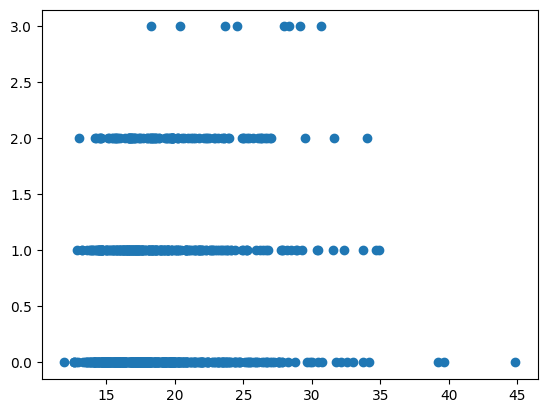

In [ ]:
plt.scatter(df['Physical-BMI'],df.sii)

<BarContainer object of 785 artists>

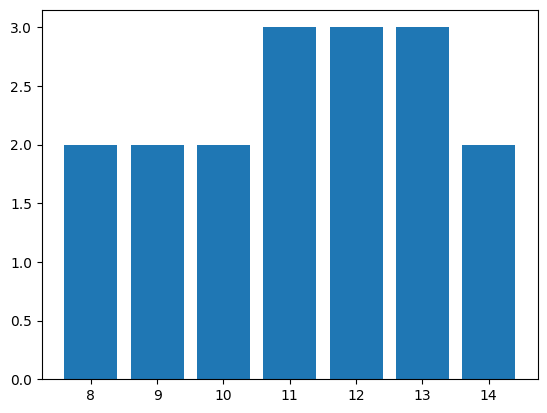

In [ ]:
plt.bar(df['Basic_Demos-Age'],df.sii)

<BarContainer object of 785 artists>

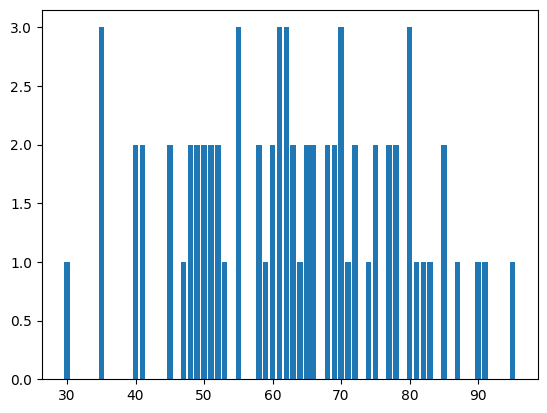

In [ ]:
plt.bar(df['CGAS-CGAS_Score'],df.sii)

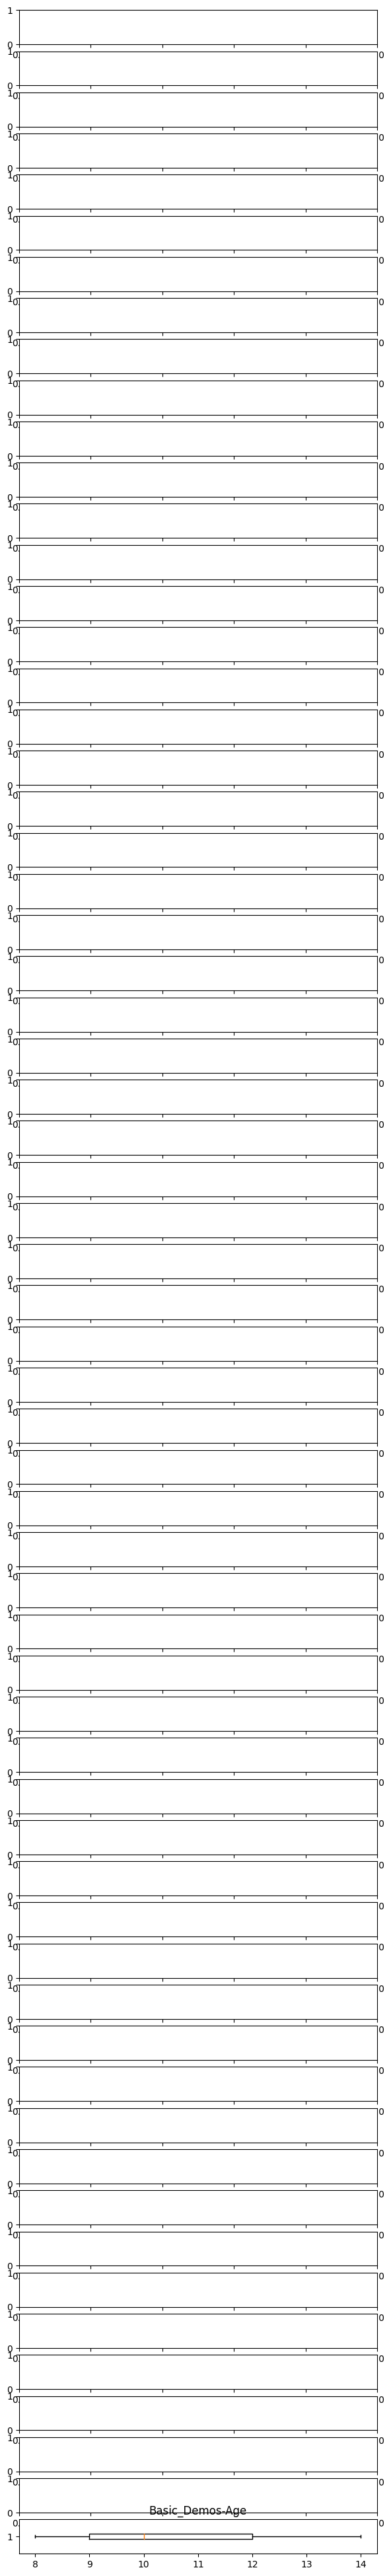

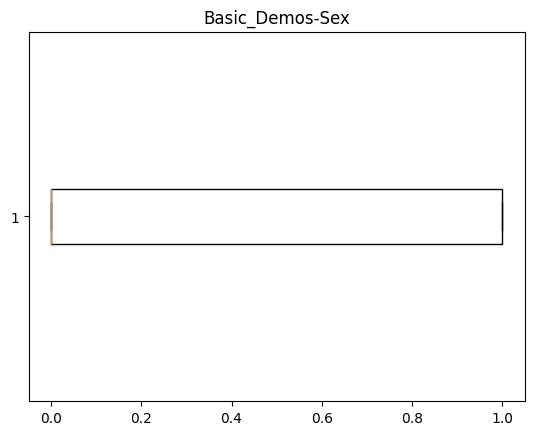

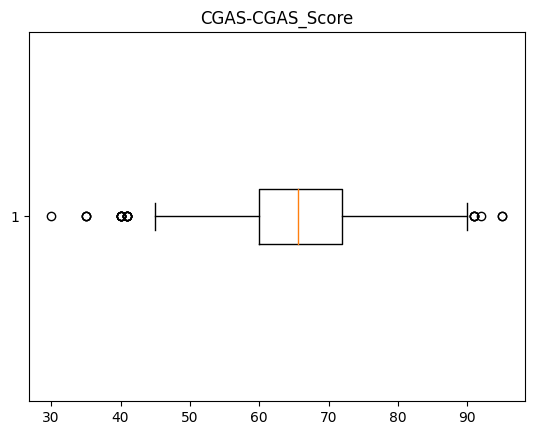

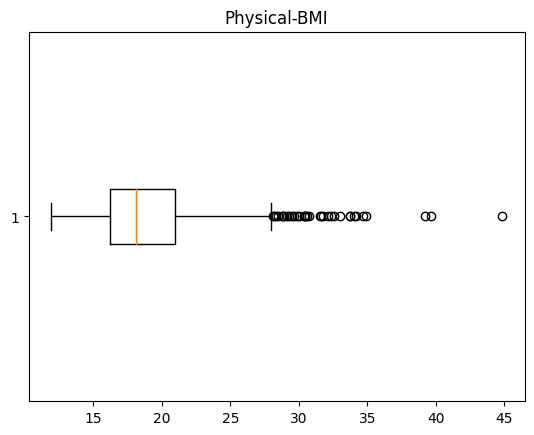

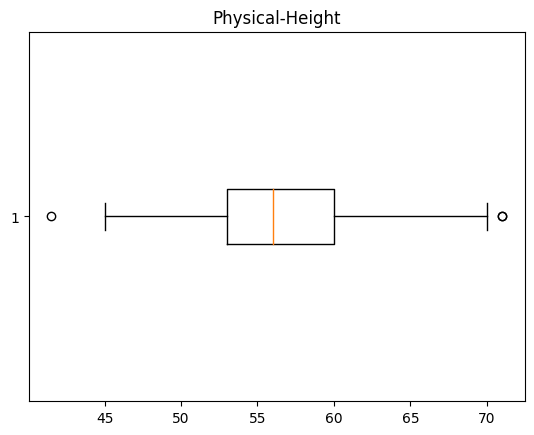

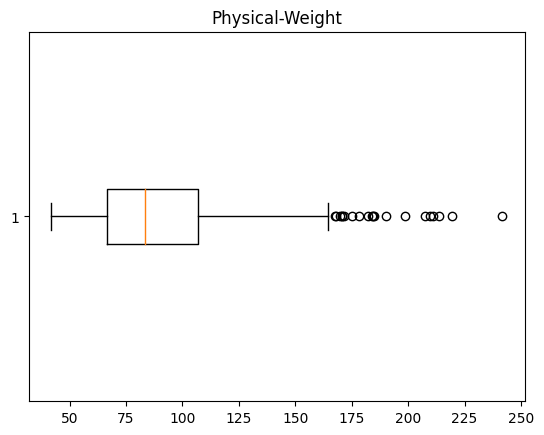

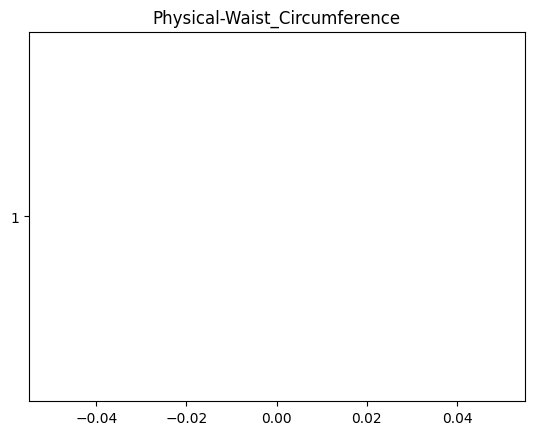

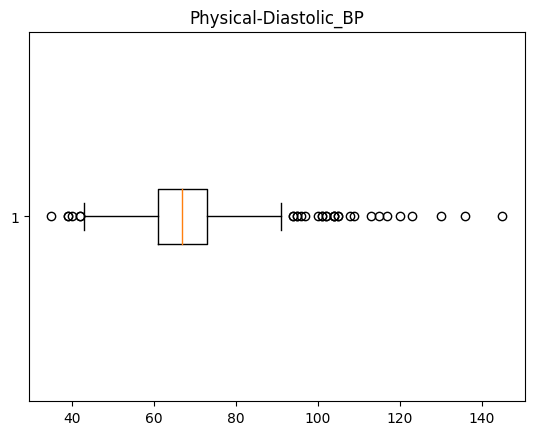

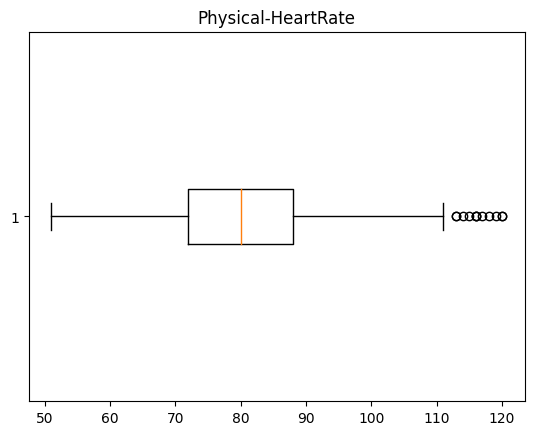

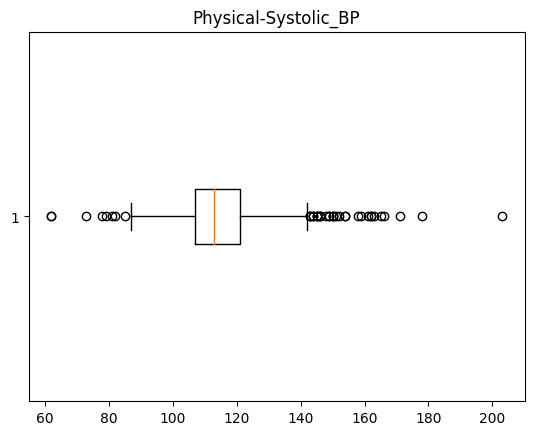

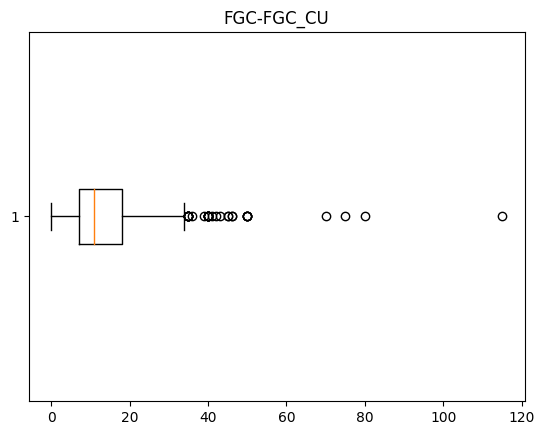

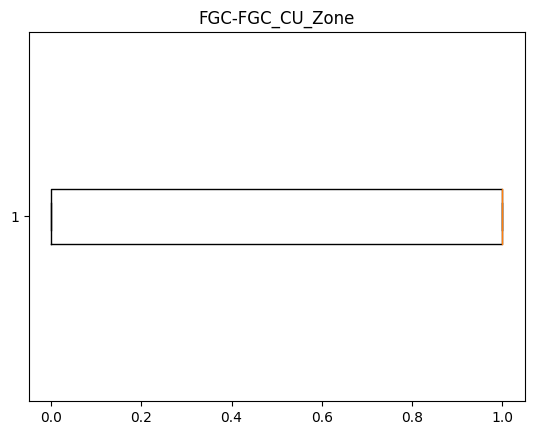

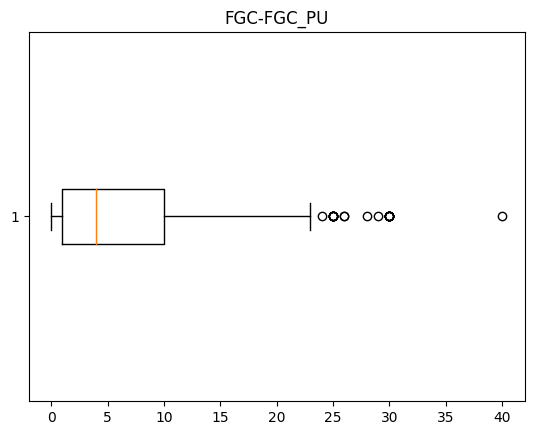

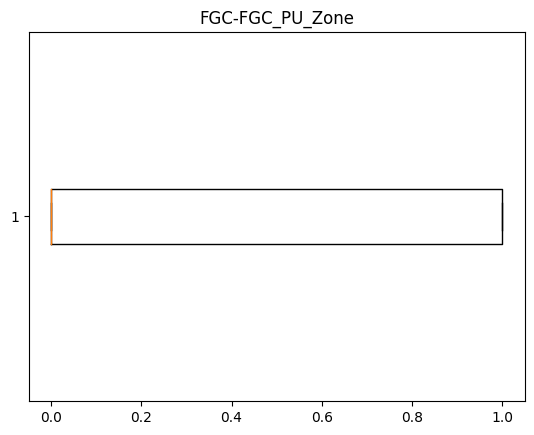

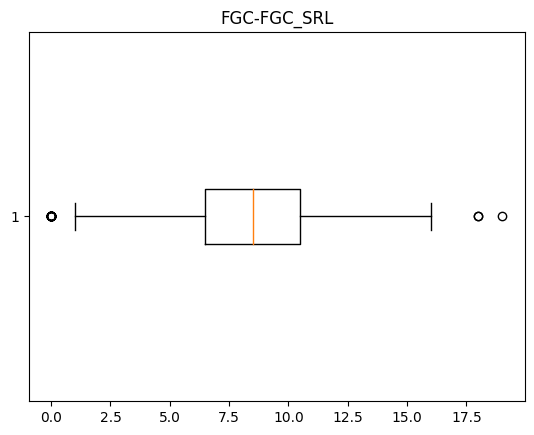

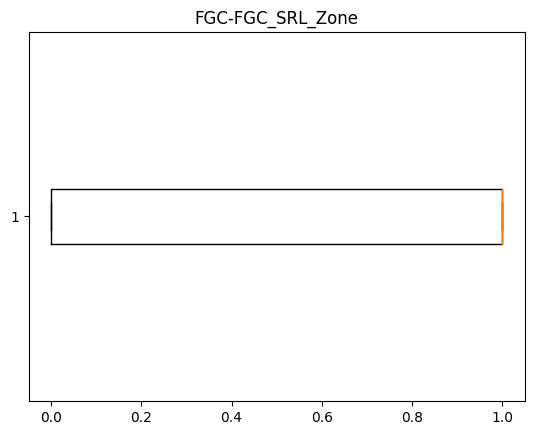

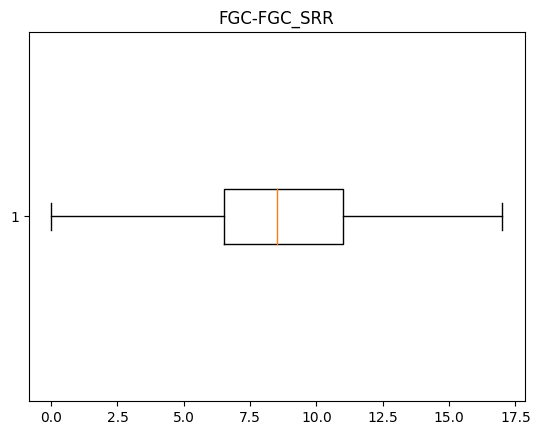

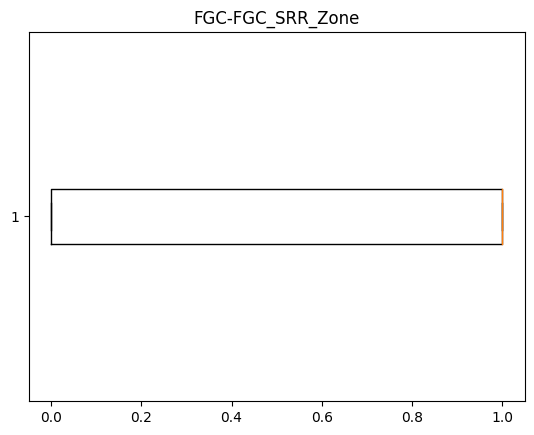

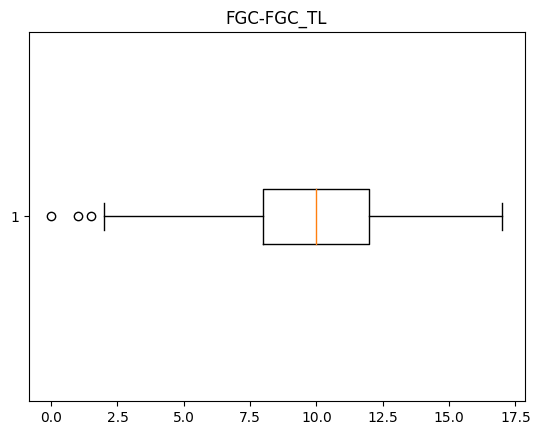

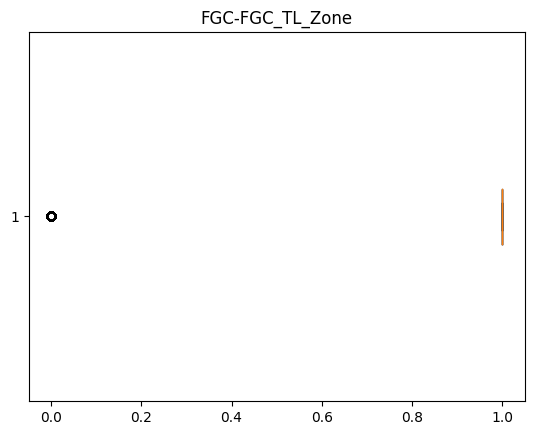

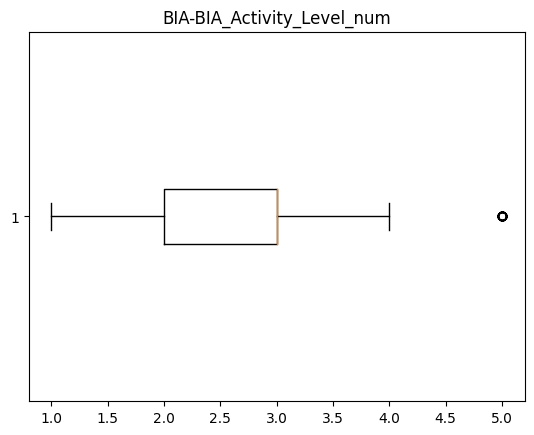

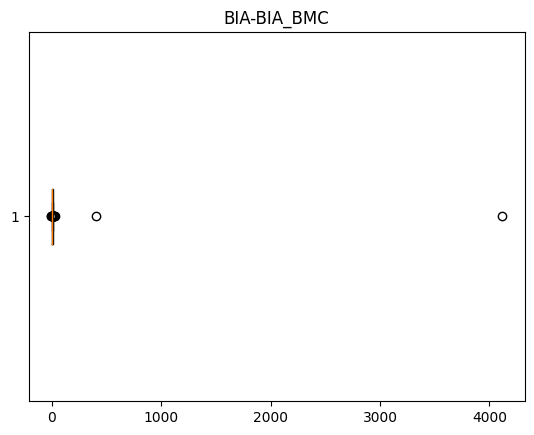

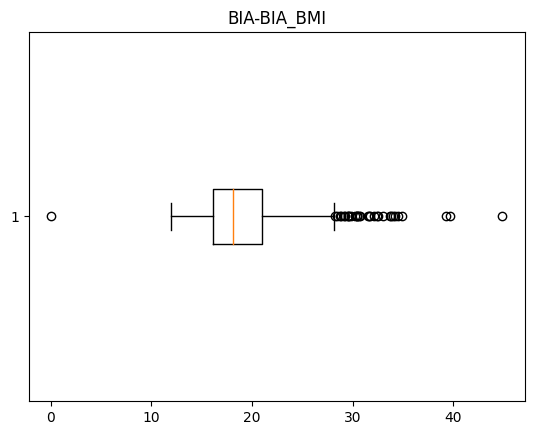

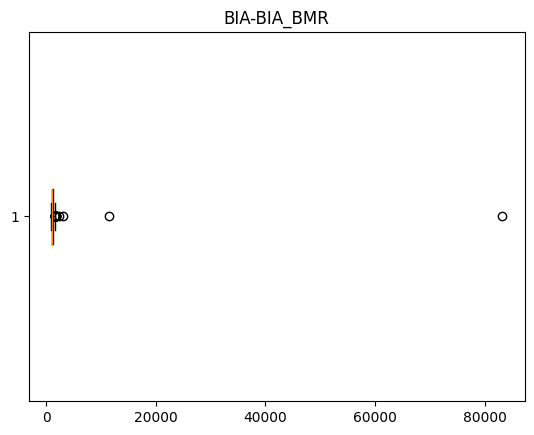

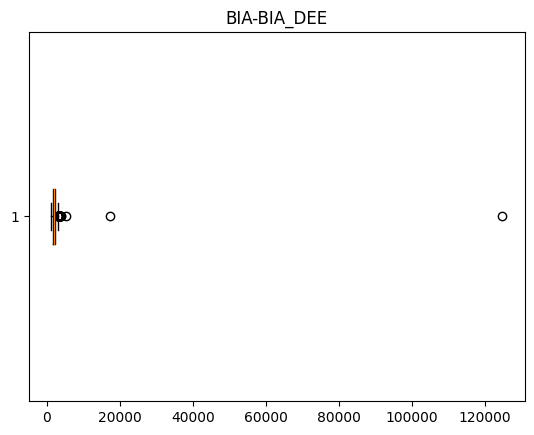

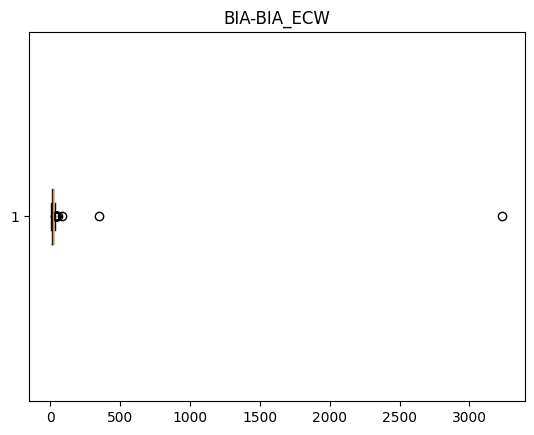

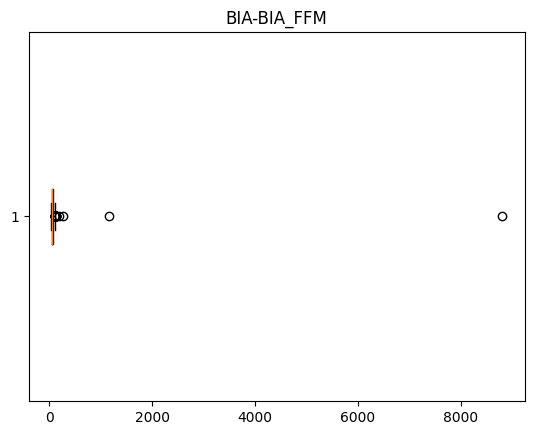

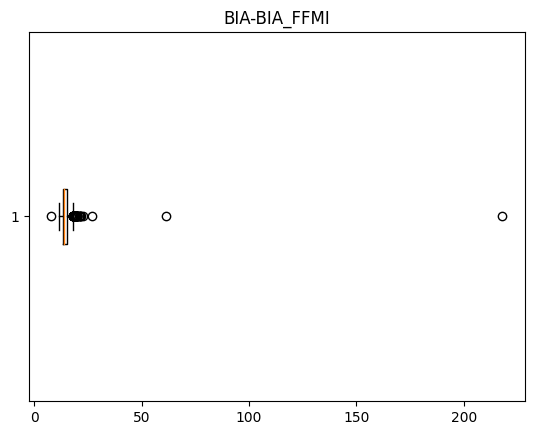

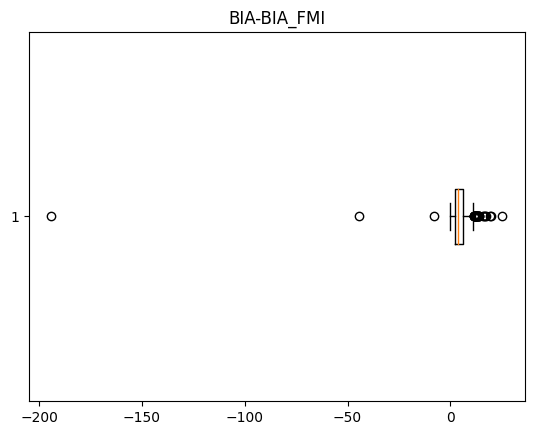

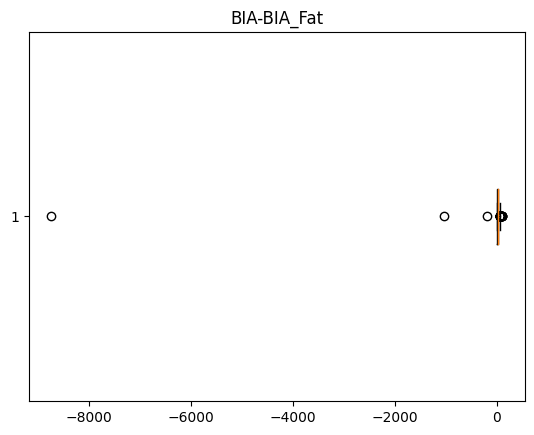

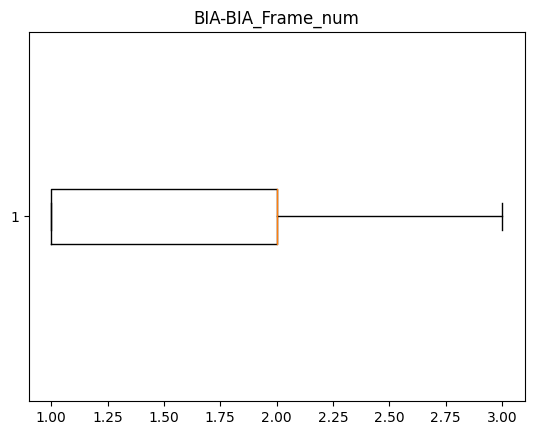

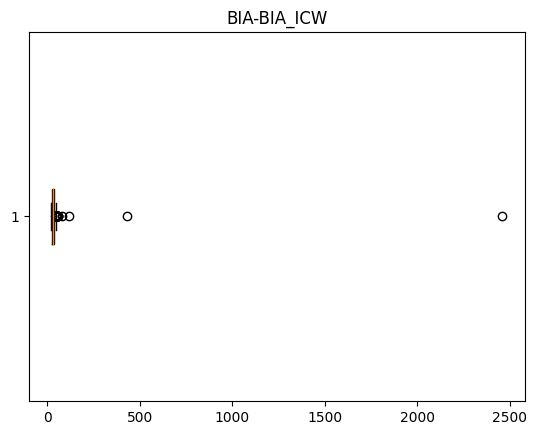

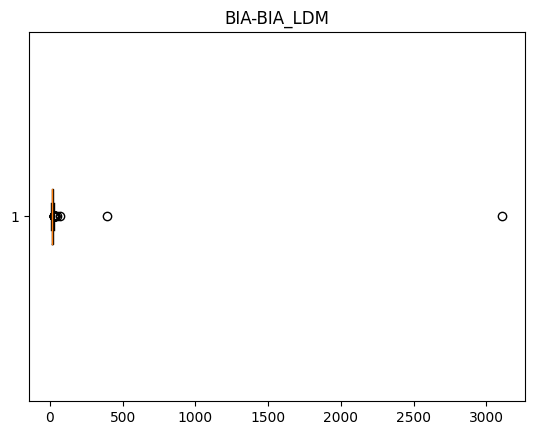

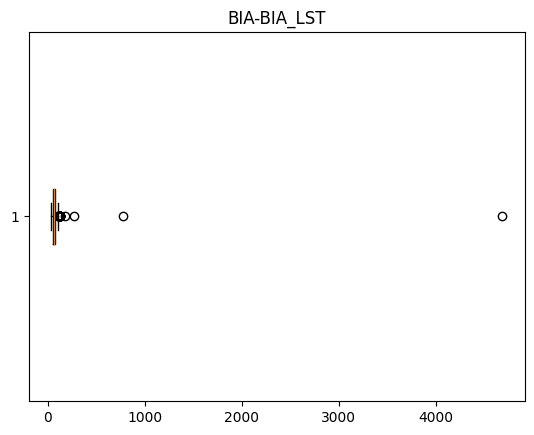

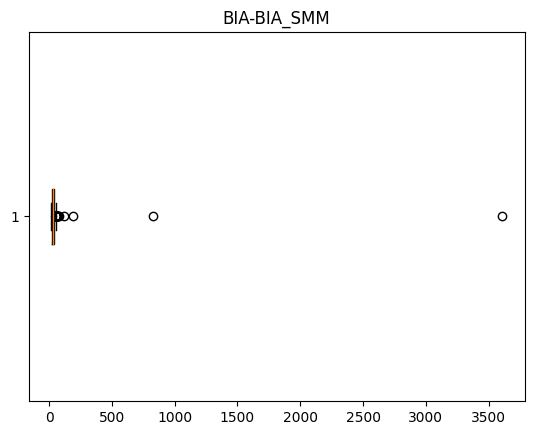

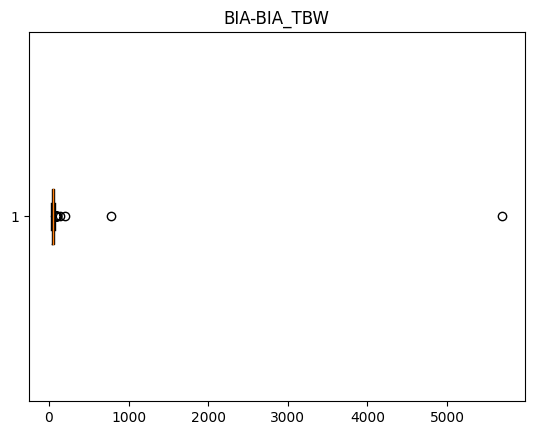

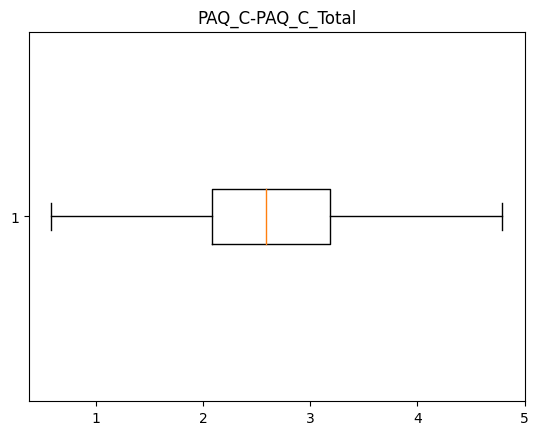

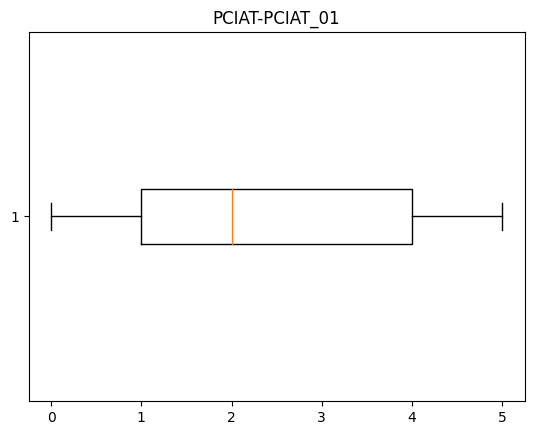

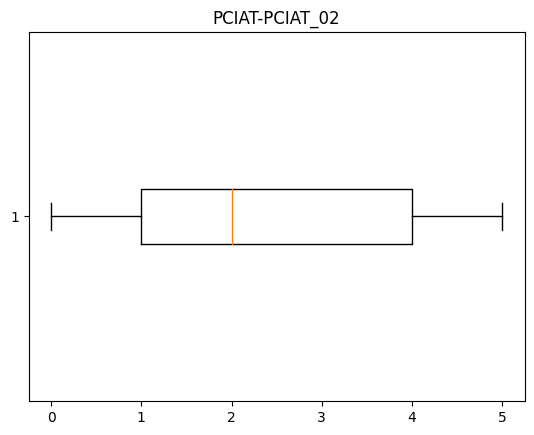

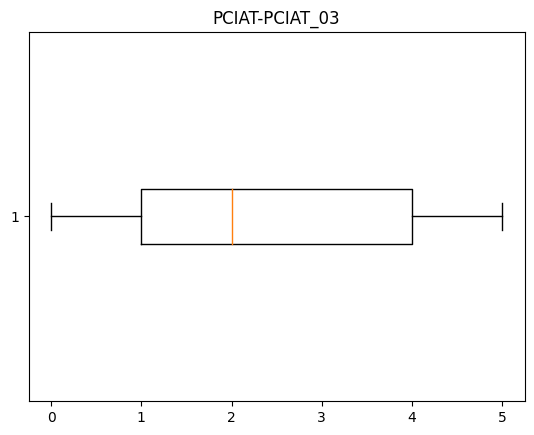

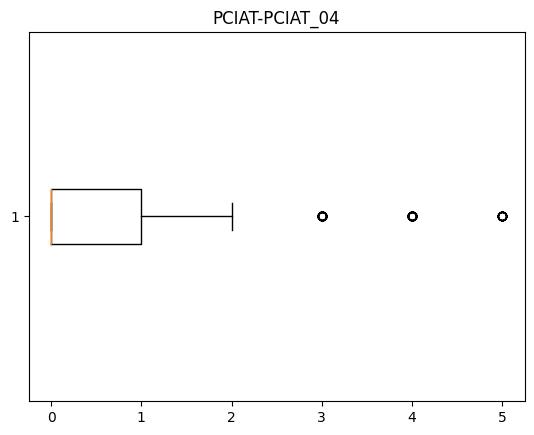

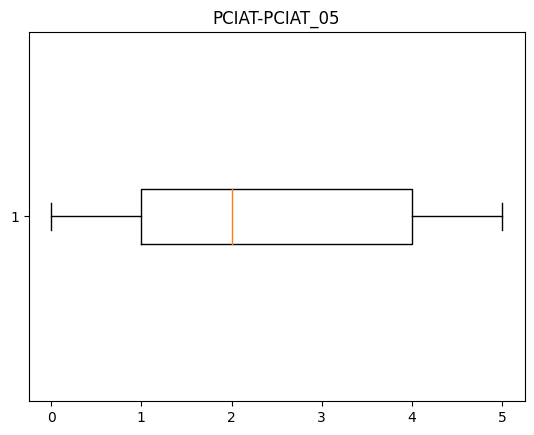

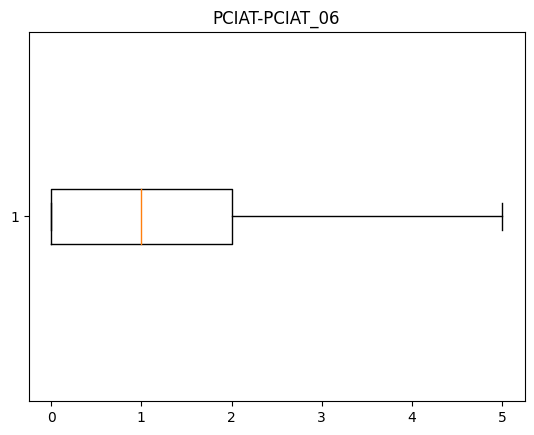

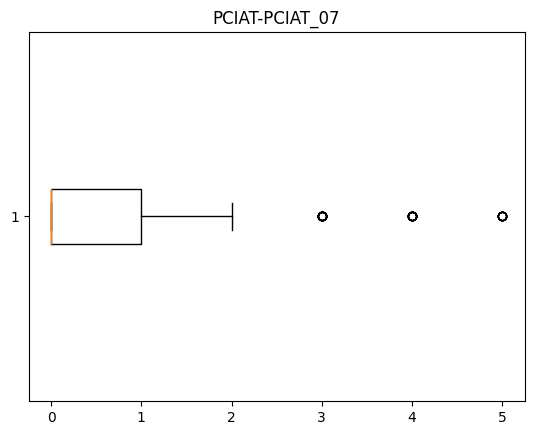

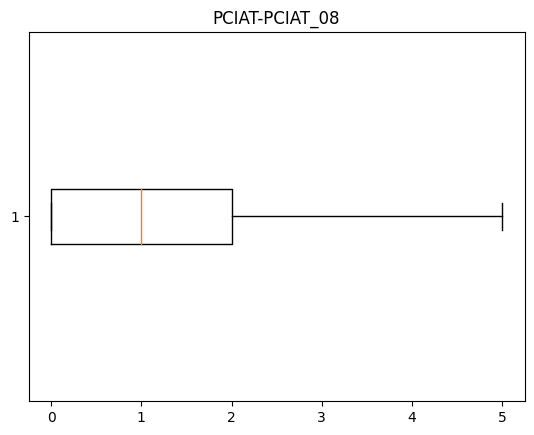

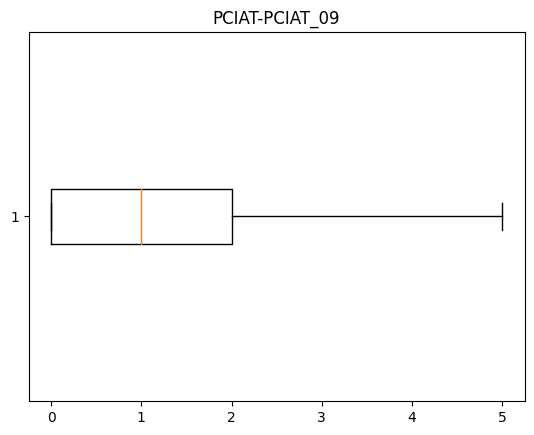

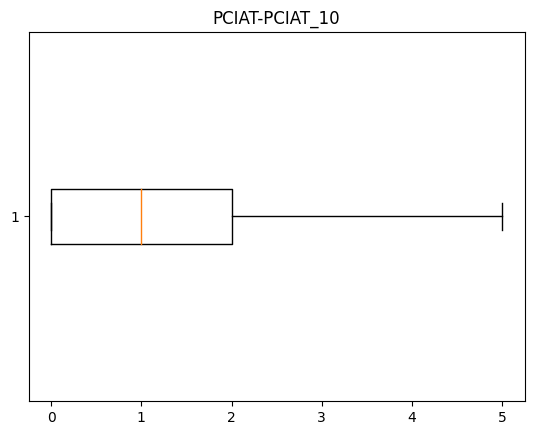

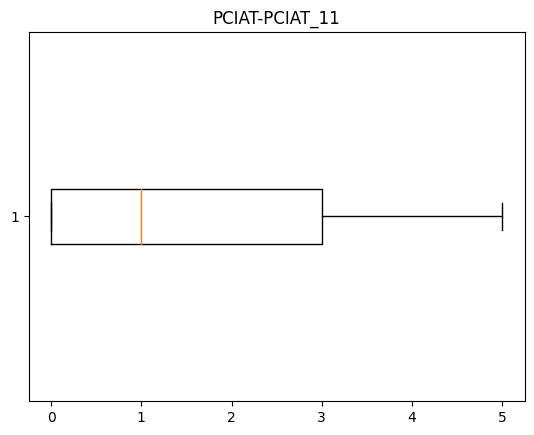

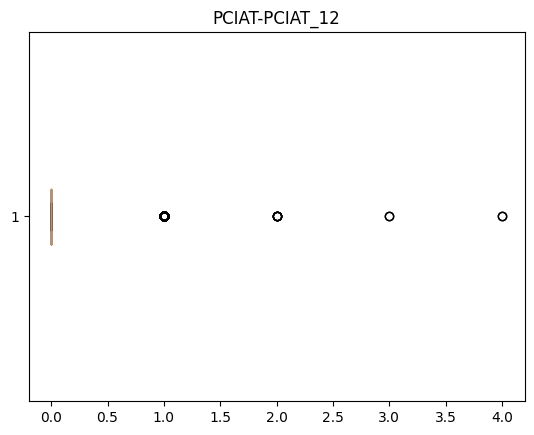

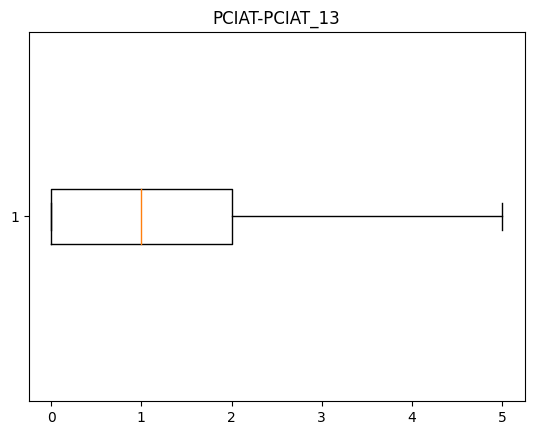

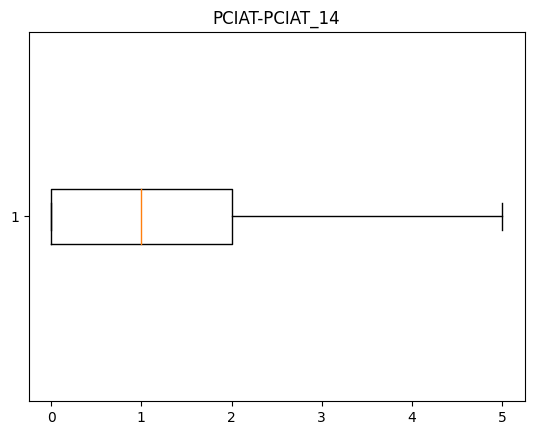

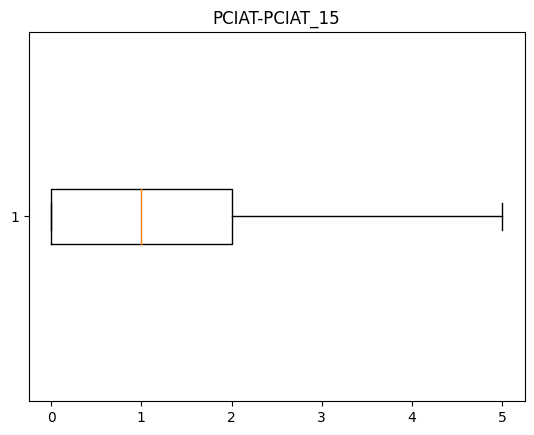

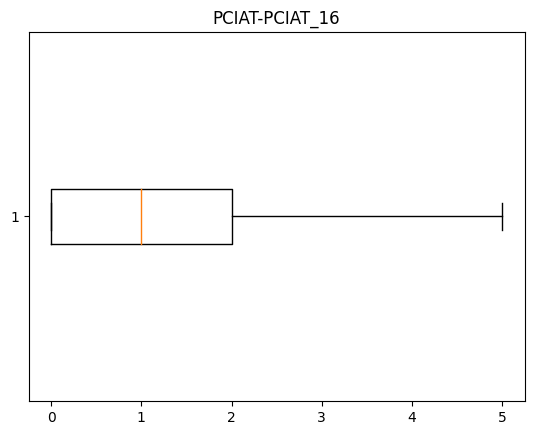

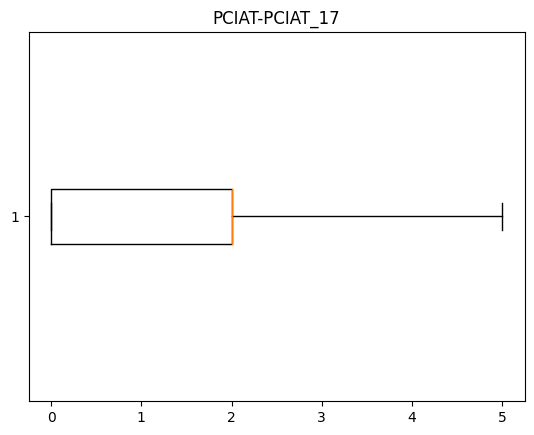

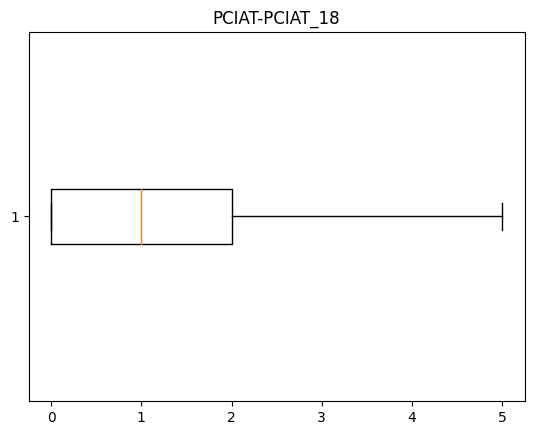

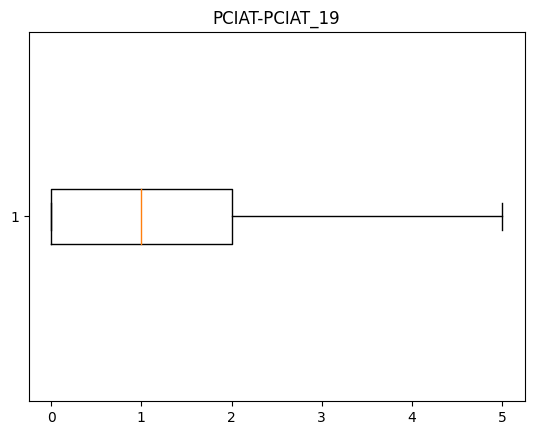

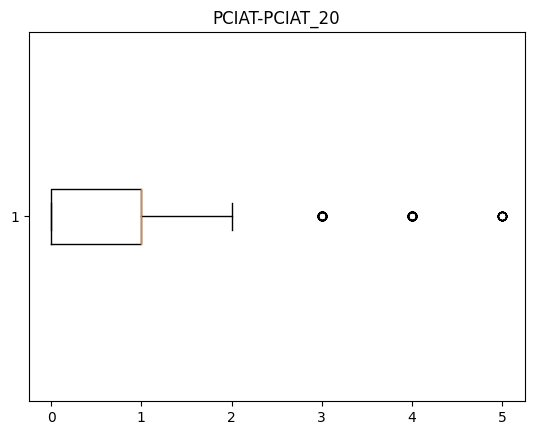

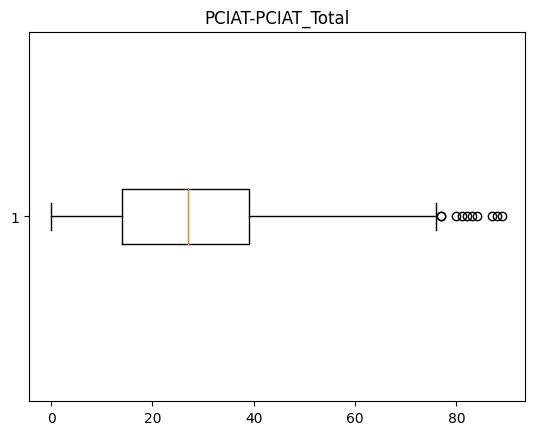

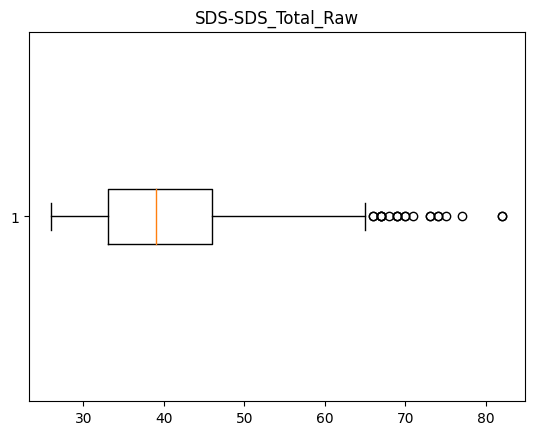

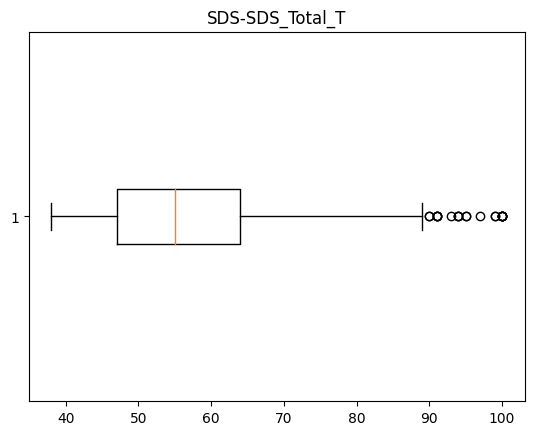

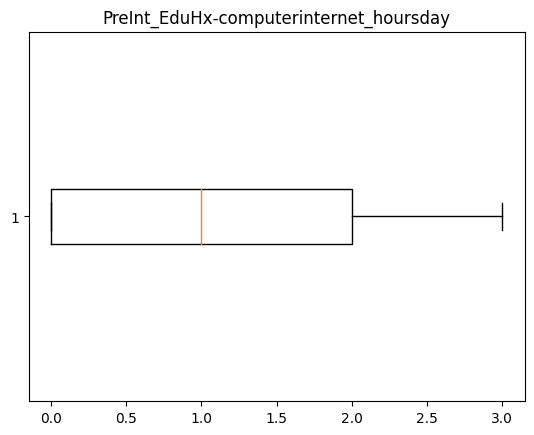

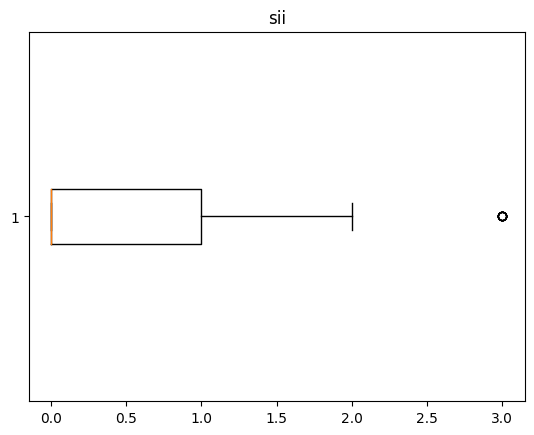

In [ ]:
num_col = [col for col in df.columns if df[col].dtype != 'object']

fig,axs = plt.subplots(len(num_col),1,figsize = (7,50))

for i,j in zip(num_col,range(len(num_col))):
  plt.title(i)
  axs[j] = plt.boxplot(df[i],vert = False)
  plt.show()

In [ ]:
mean = np.mean(df['Physical-Diastolic_BP'])
std = np.std(df['Physical-Diastolic_BP'])

lower = mean - 2 * std
upper = mean + 2 * std





mean1 = np.mean(df['Physical-HeartRate'])
std1 = np.std(df['Physical-HeartRate'])

lower1 = mean1 - 2 * std1
upper1 = mean1 + 2 * std1



mean2 = np.mean(df['FGC-FGC_PU'])
std2 = np.std(df['FGC-FGC_PU'])

lower2 = mean2 - 2 * std2
upper2 = mean2 + 2 * std2


mean3 = np.mean(df['PCIAT-PCIAT_12'])
std3 = np.std(df['PCIAT-PCIAT_12'])

lower3 = mean3 - 2 * std3
upper3 = mean3 + 2 * std3


mean4 = np.mean(df['SDS-SDS_Total_Raw'])
std4 = np.std(df['SDS-SDS_Total_Raw'])

lower4 = mean4 - 2 * std4
upper4 = mean4 + 2 * std4


mean5 = np.mean(df['SDS-SDS_Total_T'])
std5 = np.std(df['SDS-SDS_Total_T'])

lower5 = mean5 - 2 * std5
upper5 = mean5 + 2 * std5

df2 = df[(df['Physical-Diastolic_BP'] >= lower) & (df['Physical-Diastolic_BP'] <= upper) &
          (df['Physical-HeartRate'] >= lower1) & (df['Physical-HeartRate'] <= upper1) &
         (df['FGC-FGC_PU'] >= lower2) & (df['FGC-FGC_PU'] <= upper2) &
         (df['PCIAT-PCIAT_12'] >= lower3) & (df['PCIAT-PCIAT_12'] <= upper3) &
(df['SDS-SDS_Total_Raw'] >= lower4) & (df['SDS-SDS_Total_Raw'] <= upper4) &
  (df['SDS-SDS_Total_T'] >= lower5) & (df['SDS-SDS_Total_T'] <= upper5)]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

cat_col = [col for col in df.columns if df[col].dtype == 'object']

for col in cat_col:
  df[col] = encoder.fit_transform(df[col])

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
1,2,9,0,1,65.588757,0,14.035590,48.00,46.0,22.0,...,0.0,0.0,0.0,0.0,0,46.0,64.0,2,0.0,0.0
3,3,9,0,0,71.000000,2,18.292347,56.00,81.6,NaN,...,3.0,4.0,1.0,44.0,2,31.0,45.0,3,0.0,1.0
5,1,13,1,3,50.000000,2,22.279952,59.50,112.2,NaN,...,1.0,2.0,1.0,34.0,2,40.0,56.0,1,0.0,1.0
6,0,10,0,1,65.588757,0,19.660760,55.00,84.6,NaN,...,4.0,1.0,0.0,20.0,3,27.0,40.0,0,3.0,0.0
12,0,13,0,1,65.588757,3,21.079065,57.75,100.0,NaN,...,2.0,2.0,1.0,31.0,0,33.0,47.0,0,1.0,1.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df.drop(columns = 'sii'))

scaled_pd = pd.DataFrame(scaled,columns = df.columns[:-1])

scaled_pd.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday
0,0.666667,0.166667,0.0,0.333333,0.547519,0.000000,0.064127,0.220339,0.021021,0.08,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.357143,0.419355,0.666667,0.000000
1,1.000000,0.166667,0.0,0.000000,0.630769,0.666667,0.193471,0.491525,0.199199,NaN,...,0.8,0.6,0.8,0.2,0.494382,0.666667,0.089286,0.112903,1.000000,0.000000
2,0.333333,0.833333,1.0,1.000000,0.307692,0.666667,0.314636,0.610169,0.352352,NaN,...,0.6,0.2,0.4,0.2,0.382022,0.666667,0.250000,0.290323,0.333333,0.000000
3,0.000000,0.333333,0.0,0.333333,0.547519,0.000000,0.235051,0.457627,0.214214,NaN,...,0.2,0.8,0.2,0.0,0.224719,1.000000,0.017857,0.032258,0.000000,1.000000
4,0.000000,0.833333,0.0,0.333333,0.547519,1.000000,0.278147,0.550847,0.291291,NaN,...,0.2,0.4,0.4,0.2,0.348315,0.000000,0.125000,0.145161,0.000000,0.333333


In [ ]:
X = scaled_pd
y = df.sii

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)

(628, 71)
(157, 71)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')


X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)



lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98        85
         1.0       0.97      0.80      0.88        49
         2.0       0.76      0.96      0.85        23
         3.0       0.00      0.00      0.00         0

    accuracy                           0.92       157
   macro avg       0.67      0.69      0.67       157
weighted avg       0.94      0.92      0.93       157



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. 

In [ ]:
from sklearn.svm import SVC

svc = SVC()

from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'C' : [0.1,1,10,100],
    'gamma' : [1,0.1,0.01,0.001],
    'kernel' : ['linear','rbf','kernel','sigmoid']
}

random_search = RandomizedSearchCV(svc,param_grids,cv = 5,scoring = 'accuracy',verbose = 3,n_jobs = -1)

random_search.fit(X_train,y_train)

print(random_search.best_estimator_)
print(random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
SVC(C=1, gamma=0.01, kernel='linear')
{'kernel': 'linear', 'gamma': 0.01, 'C': 1}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_p

In [ ]:
svc = SVC(C=1, gamma=1, kernel='linear')

from sklearn.ensemble import AdaBoostClassifier

ada_boost = AdaBoostClassifier(
    estimator = svc,
    n_estimators = 50,
    learning_rate = 1.0,
    random_state = 42,
    algorithm='SAMME'
)

ada_boost.fit(X_train,y_train)

y_pred = ada_boost.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        87
         1.0       0.26      1.00      0.42        40
         2.0       0.80      0.14      0.24        29
         3.0       0.00      0.00      0.00         1

    accuracy                           0.28       157
   macro avg       0.27      0.28      0.16       157
weighted avg       0.21      0.28      0.15       157



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier

params = {
    'max_depth' : list(range(2,7)),
    'max_leaf_nodes' : list(range(2,100)),
    'min_samples_split' : [2,3,4]
}

random_search1 = RandomizedSearchCV(DecisionTreeClassifier(),params,cv = 5,scoring = 'accuracy',verbose = 3,n_jobs = -1)

random_search1.fit(X_train,y_train)

print(random_search1.best_params_)
print(random_search1.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'min_samples_split': 4, 'max_leaf_nodes': 87, 'max_depth': 4}
DecisionTreeClassifier(max_depth=4, max_leaf_nodes=87, min_samples_split=4)


In [ ]:
dtr = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=87, min_samples_split=4)

ada_boost1 = AdaBoostClassifier(
    estimator = dtr,
    n_estimators = 50,
    learning_rate = 1.0,
    random_state = 42,
    algorithm = 'SAMME'
)

ada_boost1.fit(X_train,y_train)

y_pred = ada_boost1.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        87
         1.0       1.00      1.00      1.00        40
         2.0       1.00      1.00      1.00        29
         3.0       1.00      1.00      1.00         1

    accuracy                           1.00       157
   macro avg       1.00      1.00      1.00       157
weighted avg       1.00      1.00      1.00       157

